True


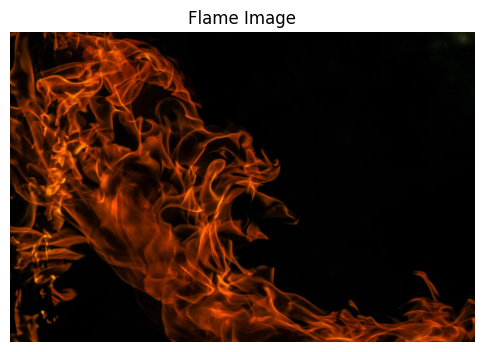

In [32]:
import os
path_fire_edge_detection = r"C:\Users\s234031\Pictures\flame.jpg"
import cv2
import matplotlib.pyplot as plt 
print(os.path.exists(path_fire_edge_detection))
img_fire_edge_detection = cv2.imread(path_fire_edge_detection)
if img_fire_edge_detection is None:
    raise FileNotFoundError("Image not Found")

img_rgb_fire = cv2.cvtColor(img_fire_edge_detection, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb_fire)
plt.axis("off")
plt.title("Flame Image")
plt.show()


Value range: (-1013.00, 874.00)


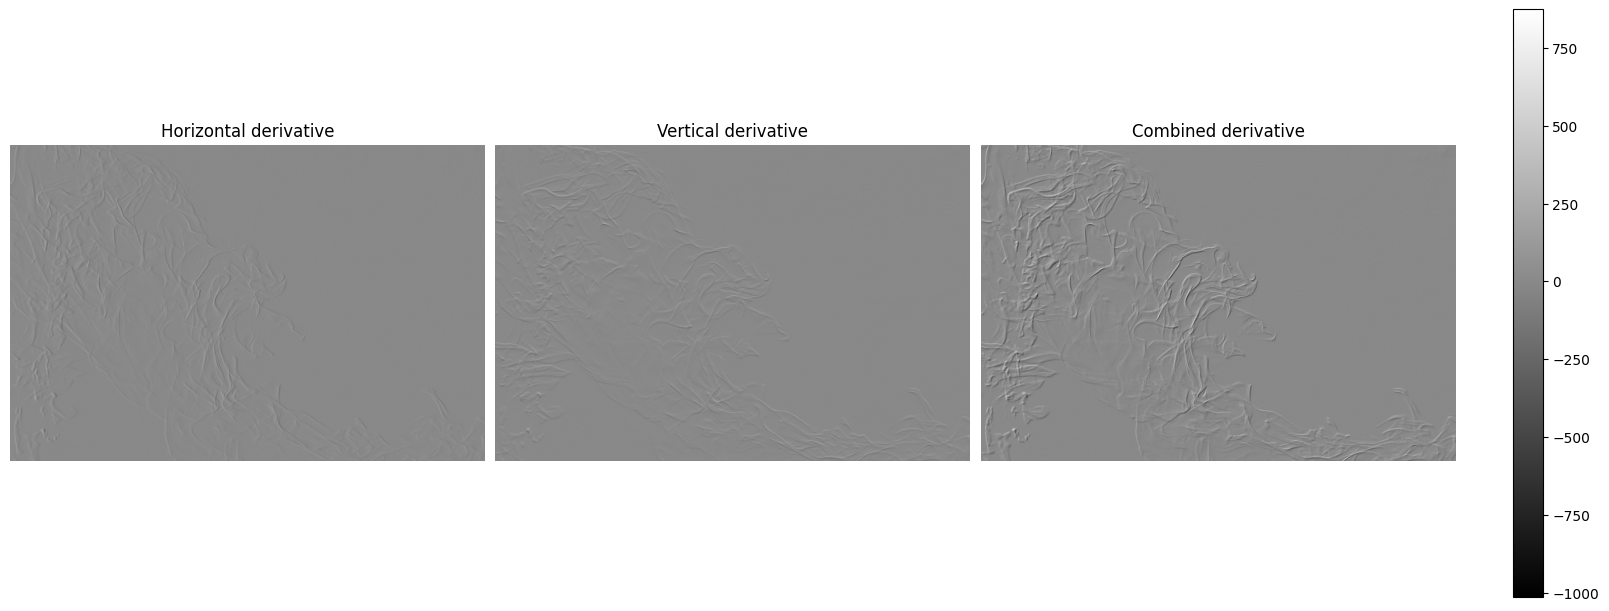

In [38]:
image = cv2.cvtColor(img_fire_edge_detection, cv2.COLOR_BGR2GRAY)
derivative_x_Sobel = cv2.Sobel(image, cv2.CV_64F, 1, 0) #cv2.CV_64F destinaiton image will have the same depth as the source, third term: order of the derivative x, 
# 4th term is the order of the derivative y
derivative_y_Sobel = cv2.Sobel(image, cv2.CV_64F, 0, 1)

derivative_combined_Sobel = cv2.addWeighted(derivative_x, 0.5, derivative_y, 0.5, 0) # Combine derivatives with 50 - 50 influence in the final image 

min_value_Sobel = min(derivative_x_Sobel.min(), derivative_y_Sobel.min(), derivative_combined_Sobel.min())
max_value_Sobel = max(derivative_x_Sobel.max(), derivative_y_Sobel.max(), derivative_combined_Sobel.max())

print(f"Value range: ({min_value_Sobel:.2f}, {max_value_Sobel:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

axes[0].imshow(derivative_x_Sobel, cmap='gray', vmin=min_value_Sobel, vmax=max_value_Sobel)
axes[0].set_title("Horizontal derivative")
axes[0].axis('off')

image_1_Sobel = axes[1].imshow(derivative_y_Sobel, cmap='gray', vmin=min_value_Sobel, vmax=max_value_Sobel)
axes[1].set_title("Vertical derivative")
axes[1].axis('off')

image_2_Sobel = axes[2].imshow(derivative_combined_Sobel, cmap='gray', vmin=min_value_Sobel, vmax=max_value_Sobel)
axes[2].set_title("Combined derivative")
axes[2].axis('off')

color_bar_Sobel = fig.colorbar(image_2_Sobel, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.025, pad=0.04)


plt.show()

Value range: (-1543.00, 1354.00)


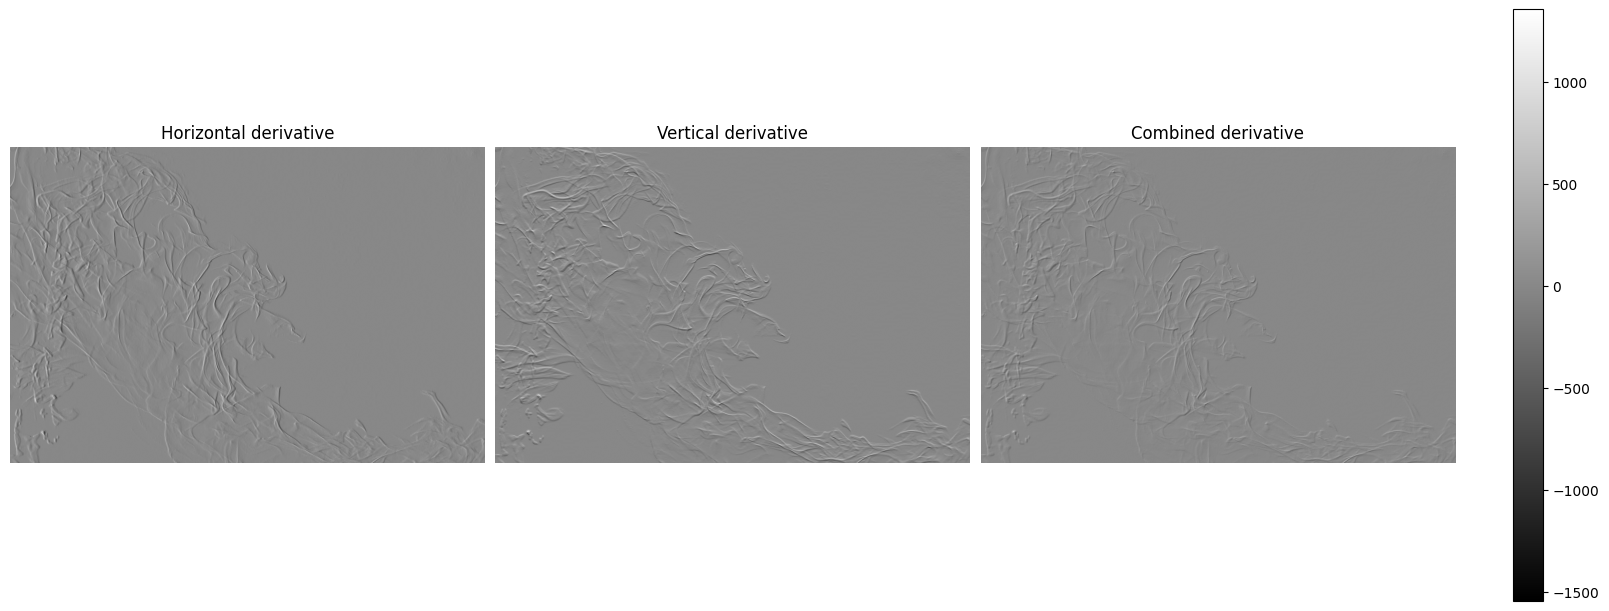

In [39]:

derivative_x_Scharr = cv2.Scharr(image, cv2.CV_64F, 1, 0) #cv2.CV_64F destinaiton image will have the same depth as the source, third term: order of the derivative x, 
# 4th term is the order of the derivative y
derivative_y_Scharr = cv2.Scharr(image, cv2.CV_64F, 0, 1)

derivative_combined_Scharr = cv2.addWeighted(derivative_x, 0.5, derivative_y, 0.5, 0) # Combine derivatives with 50 - 50 influence in the final image 

min_value_Scharr = min(derivative_x_Scharr.min(), derivative_y_Scharr.min(), derivative_combined_Scharr.min())
max_value_Scharr = max(derivative_x_Scharr.max(), derivative_y_Scharr.max(), derivative_combined_Scharr.max())

print(f"Value range: ({min_value_Scharr:.2f}, {max_value_Scharr:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

axes[0].imshow(derivative_x_Scharr, cmap='gray', vmin=min_value_Scharr, vmax=max_value_Scharr)
axes[0].set_title("Horizontal derivative")
axes[0].axis('off')

image_1_Scharr = axes[1].imshow(derivative_y_Scharr, cmap='gray', vmin=min_value_Scharr, vmax=max_value_Scharr)
axes[1].set_title("Vertical derivative")
axes[1].axis('off')

image_2_Scharr = axes[2].imshow(derivative_combined_Scharr, cmap='gray', vmin=min_value_Scharr, vmax=max_value_Scharr)
axes[2].set_title("Combined derivative")
axes[2].axis('off')

color_bar = fig.colorbar(image_2_Scharr, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.025, pad=0.04)


plt.show()

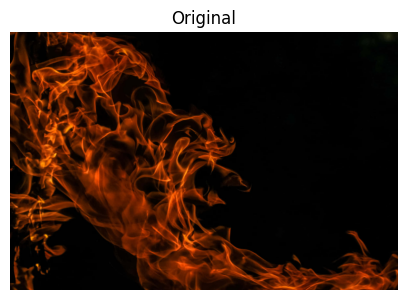

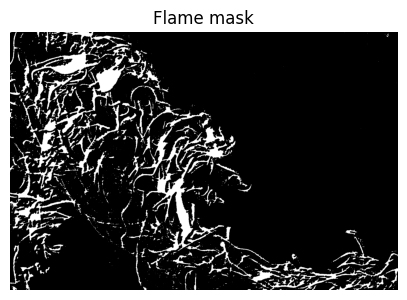

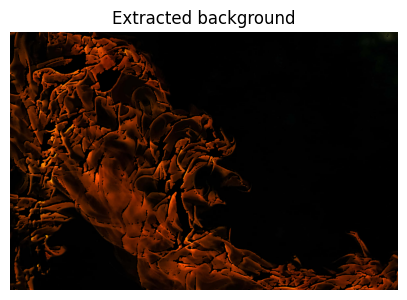

In [42]:
import numpy as np
_, edges = cv2.threshold(derivative_combined_Sobel, 50, 255, cv2.THRESH_BINARY)
edges = edges.astype(np.uint8)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)


contours, _ = cv2.findContours(
    edges_closed,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

mask = np.zeros_like(image)

cv2.drawContours(mask, contours, -1, color=255, thickness=cv2.FILLED)
flame = cv2.bitwise_and(img_fire_edge_detection, img_fire_edge_detection, mask=mask)
background_mask = cv2.bitwise_not(mask)
background = cv2.bitwise_and(img_fire_edge_detection, img_fire_edge_detection, mask=background_mask)
import matplotlib.pyplot as plt

def show(title, image):
    plt.figure(figsize=(5,5))
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis("off")
    plt.show()

show("Original", img_fire_edge_detection)
#show("Sobel magnitude", derivative_combined_Sobel)
#show("Binary edges", edges)
#show("Closed edges", edges_closed)
show("Flame mask", mask)
#show("Extracted flame", flame)
show("Extracted background", background)
